In [2]:
import pandas as pd
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random 
from latent_regularizer import*

In [92]:
def draw_gmm_samples(num_samples, gmm_centers, gmm_std):
    num_gmm_centers, dimension = gmm_centers.shape
    print(num_gmm_centers, dimension)
    samples = []
    components = []
    for _ in range(num_samples):
        component = np.random.choice(range(num_gmm_centers))

        component_mean = gmm_centers[component, :]
        component_cov = torch.eye(dimension) * gmm_std

        distribution = torch.distributions.multivariate_normal.MultivariateNormal(
            loc=component_mean, covariance_matrix=component_cov)

        sample = distribution.sample((1,))
        samples.append(sample)
        components.append(component)
    samples = torch.vstack(samples)

    return samples, components

In [93]:
def generate_5_gmm_centers(num_pairs, range_start):
    import random
    unique_pairs = []
    for _ in range(num_pairs):
        num1 = random.uniform(range_start, range_start+6)
        num2 = random.uniform(range_start+6, range_start+12)
        num3 = random.uniform(range_start+12, range_start+18)
        num4 = random.uniform(range_start+18, range_start+24)
        num5 = random.uniform(range_start+30, range_start+36)
        unique_pairs.append((num1, num2, num3, num4, num5))
    gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
    return gmm_centers

[[-20.739515 ]
 [-19.05615  ]
 [ -9.904841 ]
 [ -3.1451352]
 [  6.3686085]]
Standard deviation used: 3
<class 'torch.Tensor'>
5 1


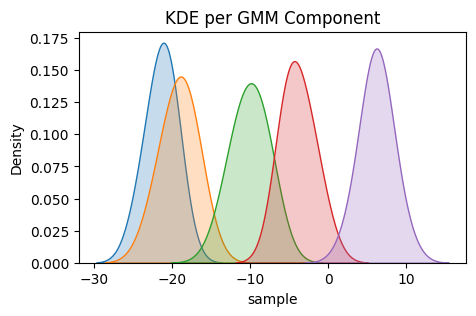

In [132]:
batch_size = 128
num_samples = 100
def gaussian_sample(num_samples):
    startpoint = random.randint(-30,0)
    gmm_centers = generate_5_gmm_centers(1, startpoint)
    print(gmm_centers.numpy())
    global gmm_std
    print(f"Standard deviation used: {gmm_std}")
    samples, components = draw_gmm_samples(num_samples, gmm_centers, gmm_std)
    data = samples.numpy()
    df = pd.DataFrame({'sample': data[:, 0], 'component': components})
    plt.figure(figsize=(5, 3))
    for comp_id in sorted(df['component'].unique()):
        subset = df[df['component'] == comp_id]
        sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
    plt.title("KDE per GMM Component")
    plt.show()
    return gmm_centers.numpy(), df, gmm_std
gmm_center, temp_data, gmm_std = gaussian_sample(num_samples)

In [101]:
# global variables 
gmm_std=2

In [108]:
%%capture
# capture suppresses output for the entire cell
# 5 gaussians, 2 latent dimensions
gmm_centers_dim1, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim2, df, gmm_std = gaussian_sample(num_samples)
df_gmm_centers_rand = pd.DataFrame(np.squeeze([gmm_centers_dim1, gmm_centers_dim2], axis=-1), columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_rand
#df_gmm_centers_rand.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_rand7.csv')

In [107]:
%%capture
# capture suppresses output for the entire cell
latent_dim = 5  # You can change this to 10, 20, or any number you want
num_centers = 5

all_centers = [] # An empty list to store the results

for _ in range(latent_dim):
    gmm_centers, _, _ = gaussian_sample(num_samples)
    all_centers.append(gmm_centers.T)
combined_centers = np.vstack(all_centers)
column_names = [f'center{i+1}' for i in range(num_centers)]
df_gmm_centers_10 = pd.DataFrame(combined_centers, columns=column_names)
df_gmm_centers_10

In [116]:
# save file 
#df_gmm_centers_10.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/5_gmm_center_5dims.csv', index=False)

### This code is looking at hardcoded gaussian centers (ones with desired specific locations relative to one another)

In [135]:
gmm_centers = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_box_small.csv')
gmm_centers = gmm_centers.iloc[:, 1:]
gmm_centers

,center1,center2,center3,center4,center5
0,-8,-8,0,8,8
1,-8,8,0,-8,8


5 1


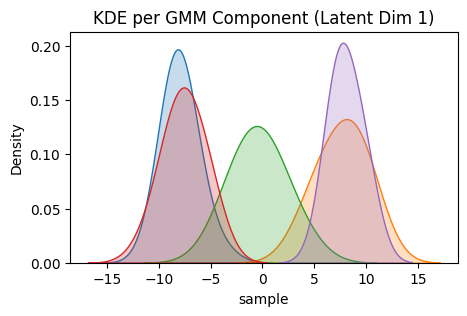

In [164]:
# This code can be used to load in previously generated centers to look at the sampled distribution 
gmm_centers = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_box_small.csv', index_col=False)
gmm_centers = torch.tensor(gmm_centers.to_numpy(), dtype=torch.float32) # some of these gmm_centers were saved with indices so they often need to be 
samples, components = draw_gmm_samples(128, gmm_centers[1:, 1:].T, gmm_std) # have to transpose gmm_centers to get them in the shape that works with the draw_gmm_samples function
data = samples.numpy()
#print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

In [165]:
# For saving gmm_centers
# df_gmm_centers = pd.DataFrame(gmm_centers.T, columns=['center1', 'center2', 'center3', 'center4', 'center5'])
# df_gmm_centers.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_two.csv')

In [167]:
# initializing gmm_centers box shape
center_0 = [-8, -8, 0, 8, 8]
center_1 = [-8, 8, 0, -8, 8]
df_gmm_centers_box = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_box
#df_gmm_centers_box.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_box_small.csv', index=False)

,center1,center2,center3,center4,center5
0,-8,-8,0,8,8
1,-8,8,0,-8,8


In [170]:
# transforms the box centers into the shape to be visualized with draw_gmm_samples
gmm_centers_5_box_np = torch.tensor(list(zip(*df_gmm_centers_box.values))).float()
gmm_centers_5_box_np

tensor([[-8., -8.],
        [-8.,  8.],
        [ 0.,  0.],
        [ 8., -8.],
        [ 8.,  8.]])

5 2
(128, 2)


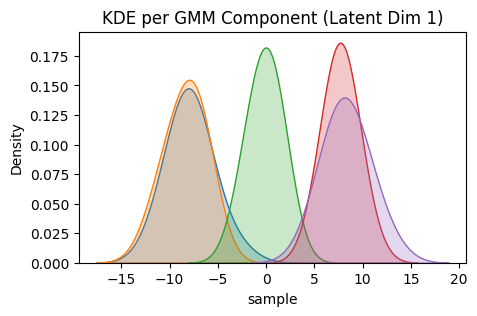

In [174]:
gmm_centers = gmm_centers_5_box_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

5 2
(128, 2)


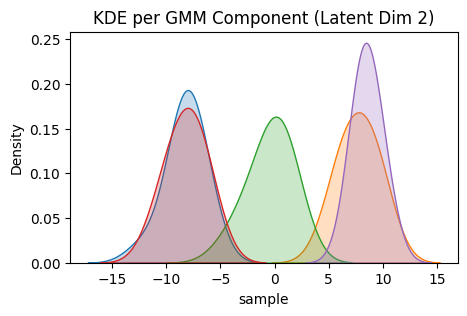

In [173]:
gmm_centers = gmm_centers_5_box_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 2)")
plt.show()

In [175]:
# intialize zigzag-like centers
center_0 = [-20, 0, -15, 15, 20]
center_1 = [-15, -20, 15, 0, 20]
df_gmm_centers_zigzag = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_zigzag

,center1,center2,center3,center4,center5
0,-20,0,-15,15,20
1,-15,-20,15,0,20


In [176]:
# put them in the shape that they need to be in to be visualized
df_gmm_centers_zigzag_np = torch.tensor(list(zip(*df_gmm_centers_zigzag.values))).float()
df_gmm_centers_zigzag_np

tensor([[-20., -15.],
        [  0., -20.],
        [-15.,  15.],
        [ 15.,   0.],
        [ 20.,  20.]])

5 2
(128, 2)


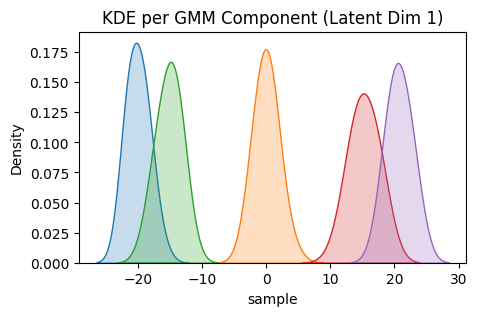

In [177]:
# visualize zigzag gmm center distribution
gmm_centers = df_gmm_centers_zigzag_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

5 2
(128, 2)


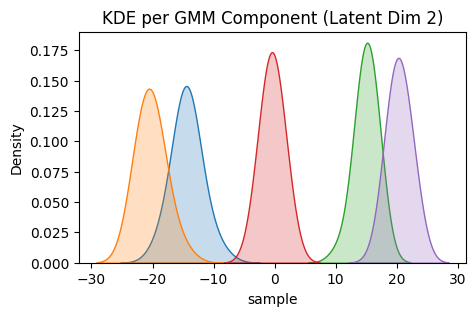

In [178]:
# visualize second dim zigzag centers
gmm_centers = df_gmm_centers_zigzag_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 2)")
plt.show()

### The following code is for generating 10 random gaussian centers

In [179]:
def generate_10_gmm_centers(num_pairs, range_start):
    import random
    unique_pairs = []
    for _ in range(num_pairs):
        num1 = random.uniform(range_start, range_start+10)
        num2 = random.uniform(range_start+10, range_start+20)
        num3 = random.uniform(range_start+20, range_start+30)
        num4 = random.uniform(range_start+30, range_start+40)
        num5 = random.uniform(range_start+40, range_start+50)
        num6 = random.uniform(range_start+50, range_start+60)
        num7 = random.uniform(range_start+60, range_start+70)
        num8 = random.uniform(range_start+70, range_start+80)
        num9 = random.uniform(range_start+80, range_start+90)
        num10 = random.uniform(range_start+90, range_start+100)
        unique_pairs.append((num1, num2, num3, num4, num5, num6, num7, num8, num9, num10))
    gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
    return gmm_centers

In [181]:
%%capture
# capture suppresses output for the entire cell
batch_size = 128
num_samples = 100
def gaussian_sample(num_samples):
    startpoint = random.randint(-50,0)
    gmm_centers = generate_10_gmm_centers(1, startpoint)
    print(gmm_centers.numpy())
    gmm_std=3
    print(f"Standard deviation used: {gmm_std}")
    samples, components = draw_gmm_samples(num_samples, gmm_centers, gmm_std)
    data = samples.numpy()
    df = pd.DataFrame({'sample': data[:, 0], 'component': components})
    plt.figure(figsize=(5, 3))
    for comp_id in sorted(df['component'].unique()):
        subset = df[df['component'] == comp_id]
        sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
    plt.title("KDE per GMM Component")
    plt.show()
    return gmm_centers.numpy(), df, gmm_std
gmm_center, temp_data, gmm_std = gaussian_sample(num_samples)